# KIVE Signal Analysis -- 9-Dimensional Fraud Detection
This notebook evaluates the separability of the 9 microservice signal dimensions that form the
KIVE expert fraud detection system.

**Signal Taxonomy:**

| Signal | Full Name | Type | What It Detects |
|--------|-----------|------|-----------------|
| TAV | Temporal Anchoring Violations | Passive | Impossible timeline overlaps in employment history |
| SVP | Specificity Variance Profile | Passive | Vague vs. concrete skill descriptions |
| FMD | Failure Memory Deficiency | Passive | Inability to recall project failures authentically |
| MDC | Market Demand Correlation | Passive | Suspiciously trending skill claims |
| TSI | Trajectory Smoothness Index | Passive | Unnaturally linear career progression |
| BES | Behavioral Entropy Service | Active | Keystroke dynamics, paste events, typing entropy |
| LQA | Linguistic Quality Assurance | Active | AI-generated phrasing artifacts |
| CCS | Cross-Candidate Similarity | Active | Response overlap across candidates |
| RSL | Response Latency Slope | Active | Suspiciously fast or flat response times |

**Passive** signals are computed from the static profile (resume analysis).
**Active** signals require live behavioral interaction (probing).


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#111111",
    "figure.facecolor": "#111111",
    "axes.edgecolor": "#333333",
    "text.color": "white",
})


In [14]:
# Resolve project root
cwd = Path.cwd()
project_root = cwd
while not (project_root / "data" / "signal_distributions.csv").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError(
            f"Could not find 'data/signal_distributions.csv' above {cwd}. "
            "Upload the 'data' folder to your session."
        )
    project_root = project_root.parent

df = pd.read_csv(project_root / "data" / "signal_distributions.csv")
print(f"Loaded {len(df)} profiles: {(df['label']=='REAL').sum()} real, {(df['label']=='FRAUD').sum()} fraud")
df.head()


Loaded 100 profiles: 58 real, 42 fraud


,id,label,tav_score,tav_confidence,tav_n_flags,svp_score,svp_confidence,svp_n_flags,fmd_score,fmd_confidence,...,bes_n_flags,lqa_score,lqa_confidence,lqa_n_flags,ccs_score,ccs_confidence,ccs_n_flags,rsl_score,rsl_confidence,rsl_n_flags
0,ff8ea6fd-6913-4ad8-86bc-64049a894c8c,REAL,0.70,0.65,1,0.764,0.78,1,0.263,0.7,...,0,0.238,0.85,0,0.05,0.46,0,0.50,0.10,0
1,d9241eff-6e24-4936-be61-75f1877a14eb,FRAUD,1.00,0.95,5,0.300,0.20,0,0.810,0.6,...,0,0.100,0.85,0,0.05,0.54,0,0.75,0.66,2
2,31612dd8-7adb-48cb-909d-5ef233f5fa18,FRAUD,1.00,0.95,5,0.300,0.20,0,0.810,0.6,...,0,0.100,0.85,0,0.30,0.54,0,0.75,0.66,2
3,72912f9a-2360-432c-97b0-1ee6a87efd0a,FRAUD,1.00,0.95,5,0.300,0.20,0,0.810,0.6,...,0,0.100,0.85,0,0.30,0.54,0,0.75,0.66,2
4,1160d065-efbe-4639-9eb3-1b977204237a,REAL,0.05,0.80,0,0.752,0.78,1,0.260,0.7,...,0,0.038,0.85,0,0.05,0.46,0,0.50,0.10,0


## Signal Distribution Analysis (KDE)
Each subplot shows the probability density for REAL vs FRAUD profiles. **Blue borders** = passive signals (free at reset). **Orange borders** = active signals (require probing).

C:\Users\mayan\AppData\Local\Temp\ipykernel_1984\136765888.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=sig, hue='label', fill=True, ax=axes[i],
C:\Users\mayan\AppData\Local\Temp\ipykernel_1984\136765888.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=sig, hue='label', fill=True, ax=axes[i],
C:\Users\mayan\AppData\Local\Temp\ipykernel_1984\136765888.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=sig, hue='label', fill=True, ax=axes[i],
C:\Users\mayan\AppData\Local\Temp\ipykernel_1984\136765888.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=sig, hue='label', fill=True, ax=axes[i],


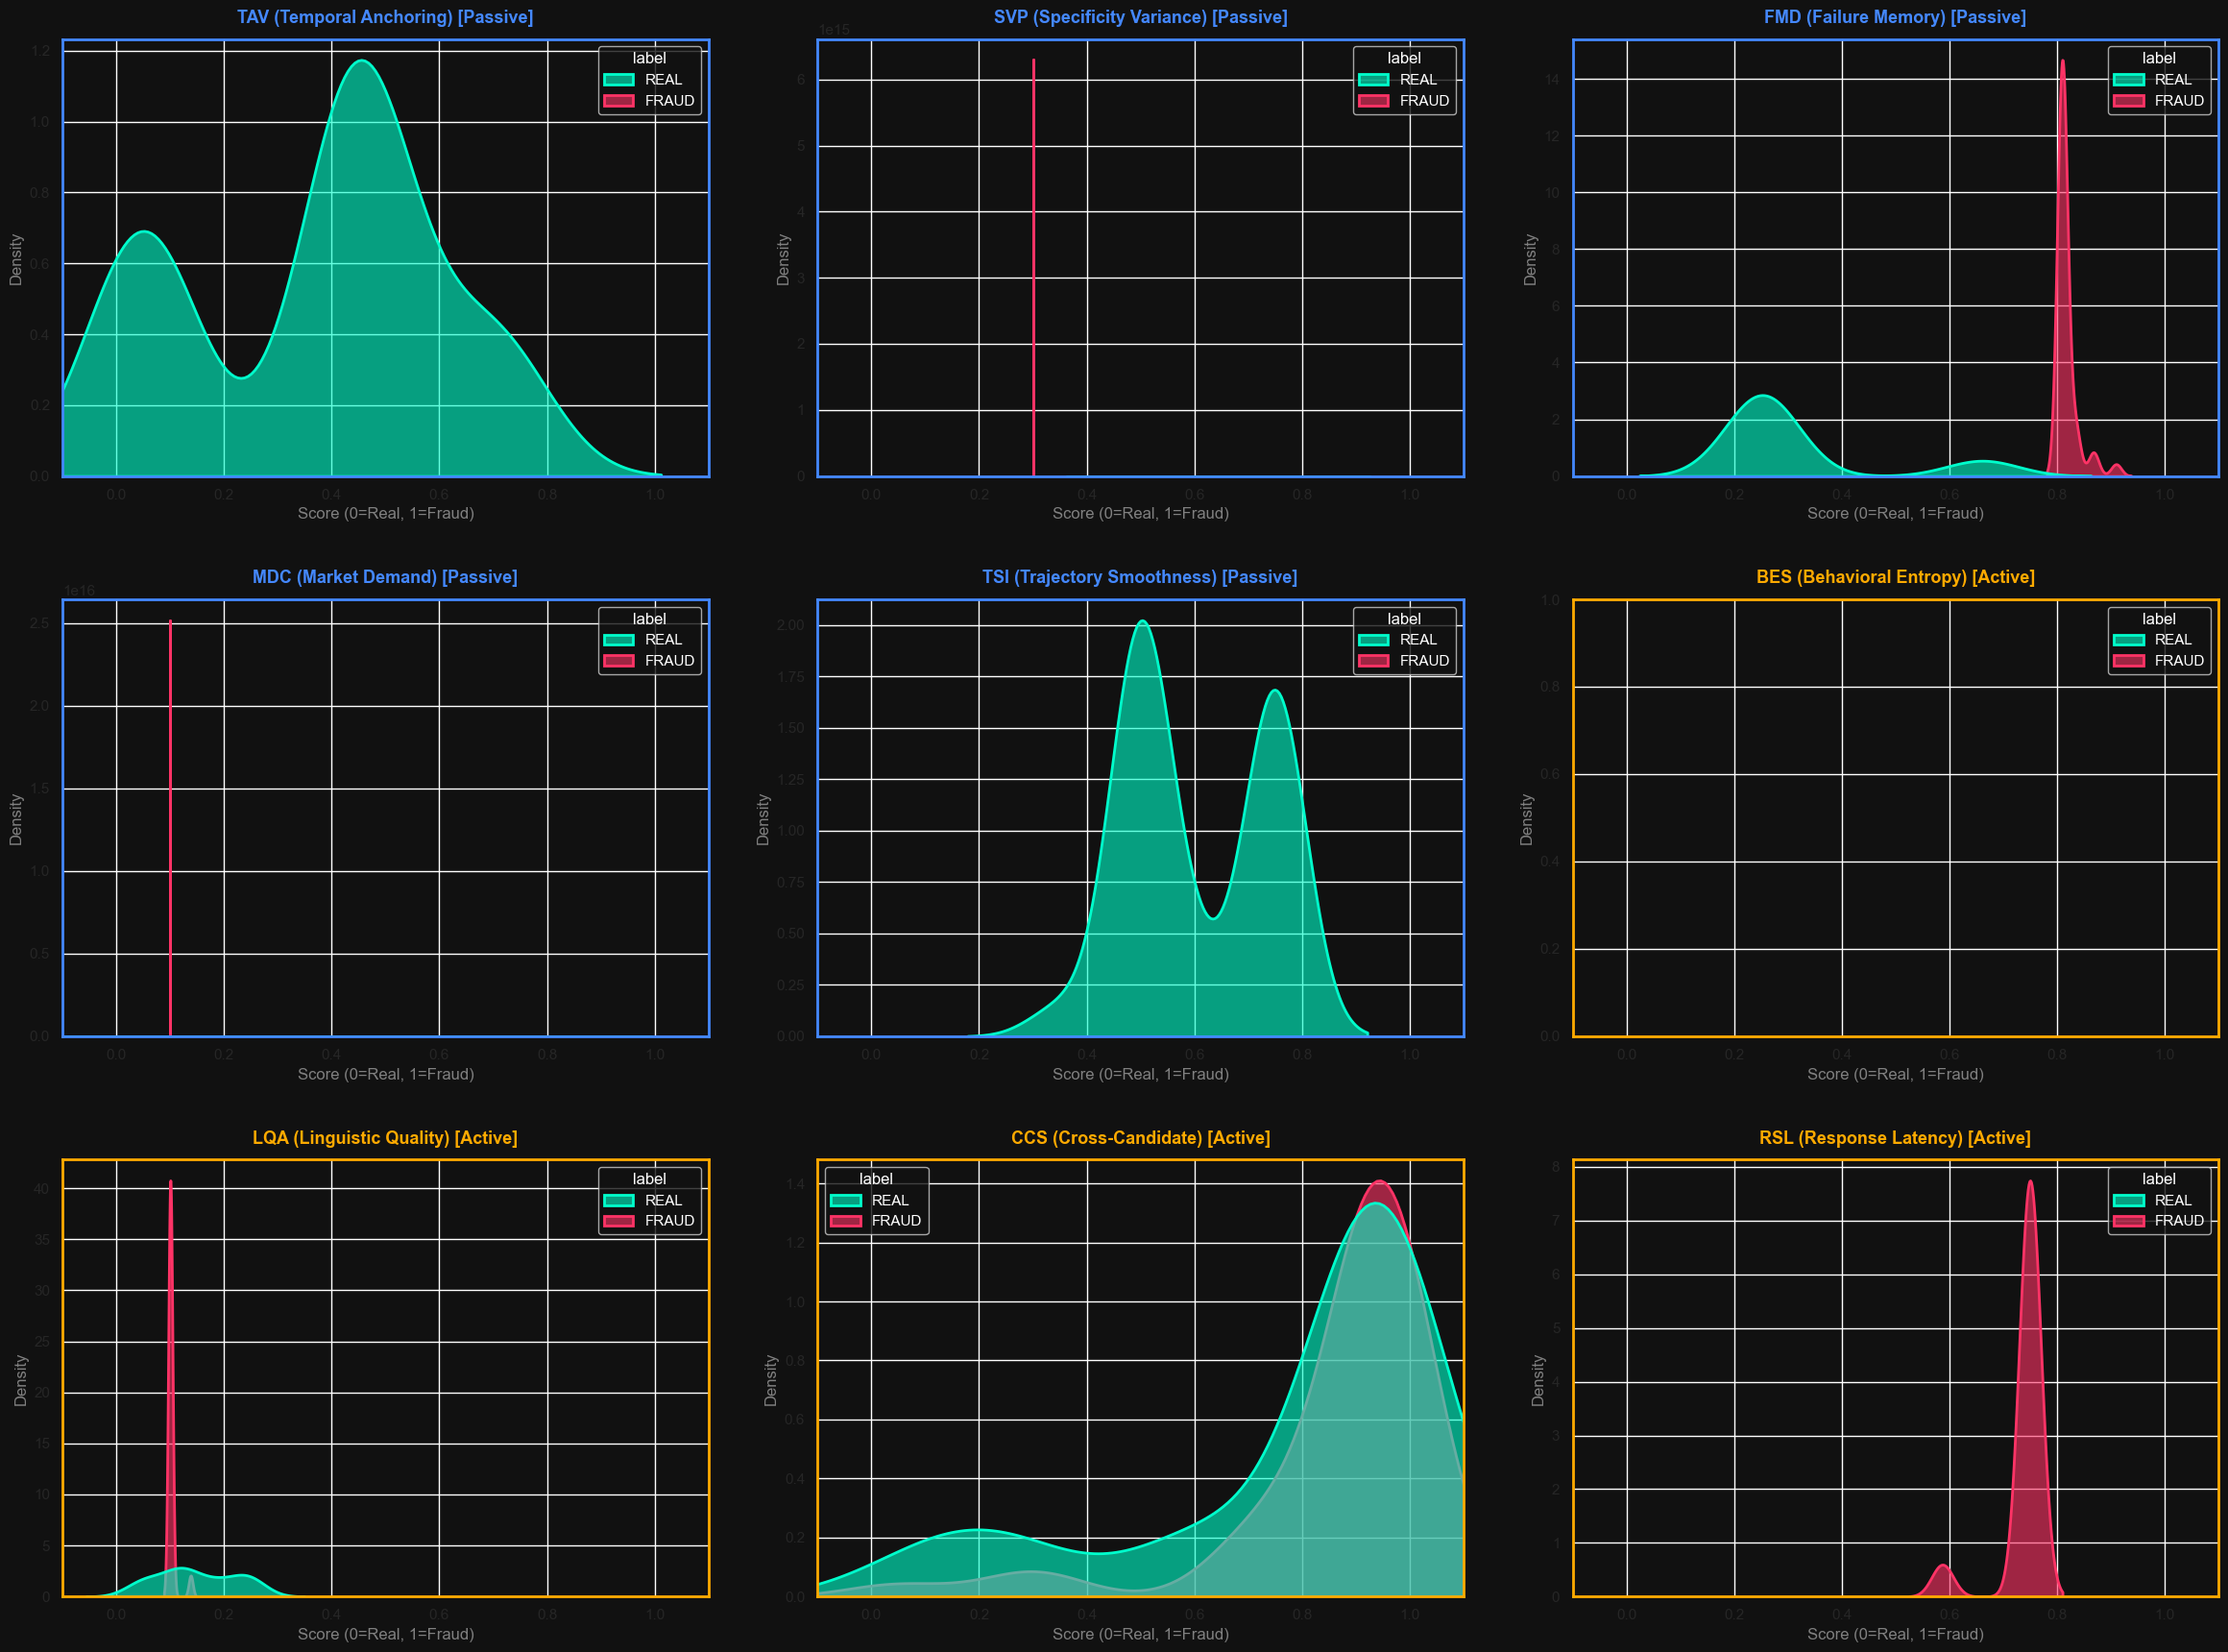

In [15]:
# --- 3x3 KDE Plot: Signal Separability ---
signals = ['tav_score', 'svp_score', 'fmd_score', 'mdc_score', 'tsi_score',
           'bes_score', 'lqa_score', 'ccs_score', 'rsl_score']
titles = [
    'TAV (Temporal Anchoring)', 'SVP (Specificity Variance)', 'FMD (Failure Memory)',
    'MDC (Market Demand)', 'TSI (Trajectory Smoothness)',
    'BES (Behavioral Entropy)', 'LQA (Linguistic Quality)', 
    'CCS (Cross-Candidate)', 'RSL (Response Latency)'
]
types = ['Passive','Passive','Passive','Passive','Passive','Active','Active','Active','Active']

fig, axes = plt.subplots(3, 3, figsize=(24, 18))
axes = axes.flatten()

for i, (sig, title, stype) in enumerate(zip(signals, titles, types)):
    if sig not in df.columns:
        axes[i].set_title(f"{title} [MISSING]", color='yellow')
        continue
    sns.kdeplot(data=df, x=sig, hue='label', fill=True, ax=axes[i],
                palette={'REAL': '#00ffcc', 'FRAUD': '#ff3366'}, alpha=0.6, linewidth=2)
    border_color = '#ffaa00' if stype == 'Active' else '#4488ff'
    for spine in axes[i].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2)
    axes[i].set_title(f"{title} [{stype}]", color=border_color, pad=12, fontsize=13, fontweight='bold')
    axes[i].set_xlim(-0.1, 1.1)
    axes[i].set_xlabel("Score (0=Real, 1=Fraud)", color='gray')
    axes[i].set_ylabel("Density", color='gray')

plt.tight_layout(pad=3.0)
out_path = project_root / "docs" / "signal_distributions.png"
if out_path.parent.exists():
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()


## Box Plot Comparison
Compact view of all 9 signal distributions side-by-side.

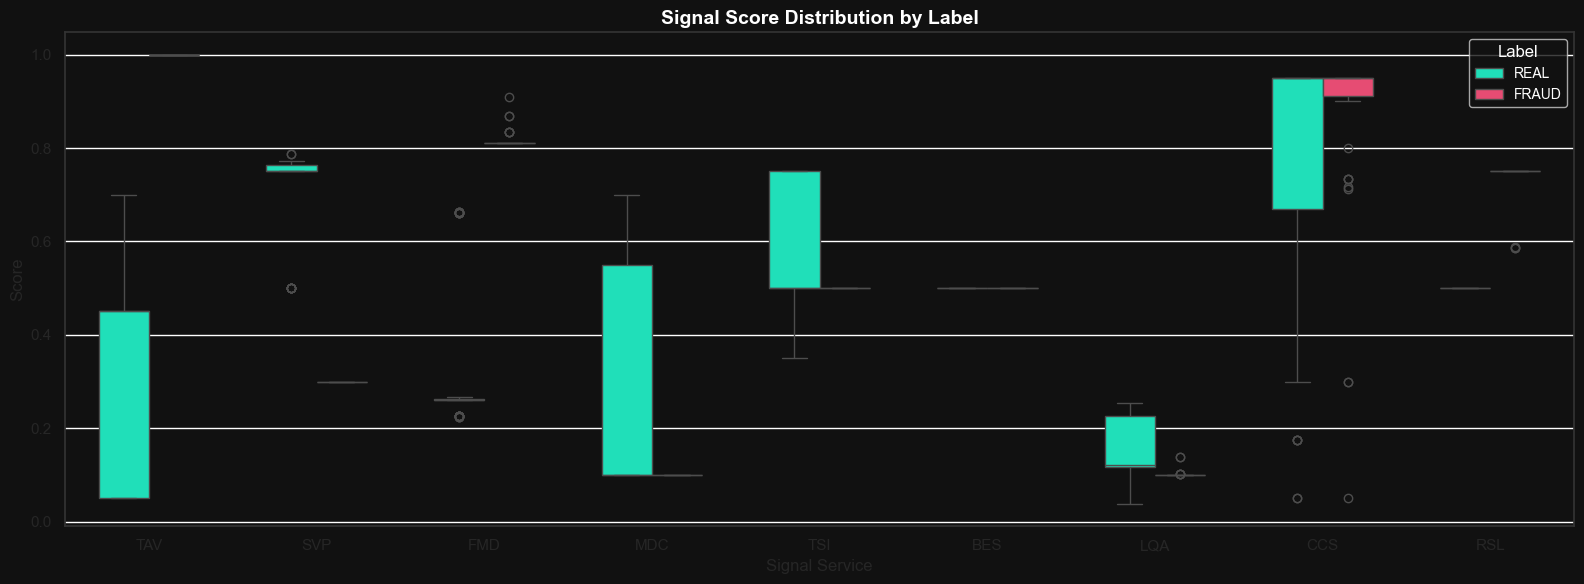

In [16]:
# --- Box Plot: Signal Score Distribution by Label ---
signals = ['tav_score','svp_score','fmd_score','mdc_score','tsi_score',
           'bes_score','lqa_score','ccs_score','rsl_score']
existing = [s for s in signals if s in df.columns]

melted = df.melt(id_vars=['label'], value_vars=existing, var_name='signal', value_name='score')
melted['signal'] = melted['signal'].str.replace('_score','').str.upper()

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=melted, x='signal', y='score', hue='label',
            palette={'REAL': '#00ffcc', 'FRAUD': '#ff3366'}, ax=ax, width=0.6)
ax.set_title("Signal Score Distribution by Label", fontsize=14, fontweight='bold', color='white')
ax.set_xlabel("Signal Service", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.legend(title="Label", fontsize=10)
plt.tight_layout()
plt.show()


## Separability Statistics
Quantitative assessment: mean gap, IQR overlap, and pass/fail separability for each signal.

In [17]:
# --- Separability Statistics ---
signals = ['tav_score','svp_score','fmd_score','mdc_score','tsi_score',
           'bes_score','lqa_score','ccs_score','rsl_score']
existing = [s for s in signals if s in df.columns]

rows = []
for sig in existing:
    real = df[df['label']=='REAL'][sig]
    fraud = df[df['label']=='FRAUD'][sig]
    gap = abs(fraud.mean() - real.mean())
    overlap = max(0, min(fraud.quantile(0.75), real.quantile(0.75)) - max(fraud.quantile(0.25), real.quantile(0.25)))
    rows.append({
        'Signal': sig.replace('_score','').upper(),
        'Real Mean': f"{real.mean():.3f}",
        'Fraud Mean': f"{fraud.mean():.3f}",
        'Gap': f"{gap:.3f}",
        'IQR Overlap': f"{overlap:.3f}",
        'Separable': 'YES' if gap > 0.15 else 'WEAK'
    })

sep_df = pd.DataFrame(rows)
print("\n=== Signal Separability Report ===")
print(sep_df.to_string(index=False))



=== Signal Separability Report ===
Signal Real Mean Fraud Mean   Gap IQR Overlap Separable
   TAV     0.369      1.000 0.631       0.000       YES
   SVP     0.711      0.300 0.411       0.000       YES
   FMD     0.316      0.817 0.502       0.000       YES
   MDC     0.240      0.100 0.140       0.000      WEAK
   TSI     0.605      0.500 0.105       0.000      WEAK
   BES     0.500      0.500 0.000       0.000      WEAK
   LQA     0.148      0.102 0.046       0.000      WEAK
   CCS     0.784      0.865 0.080       0.037      WEAK
   RSL     0.500      0.738 0.238       0.000       YES


## Cross-Signal Correlation
Correlation heatmaps reveal whether signals carry independent information or are redundant.

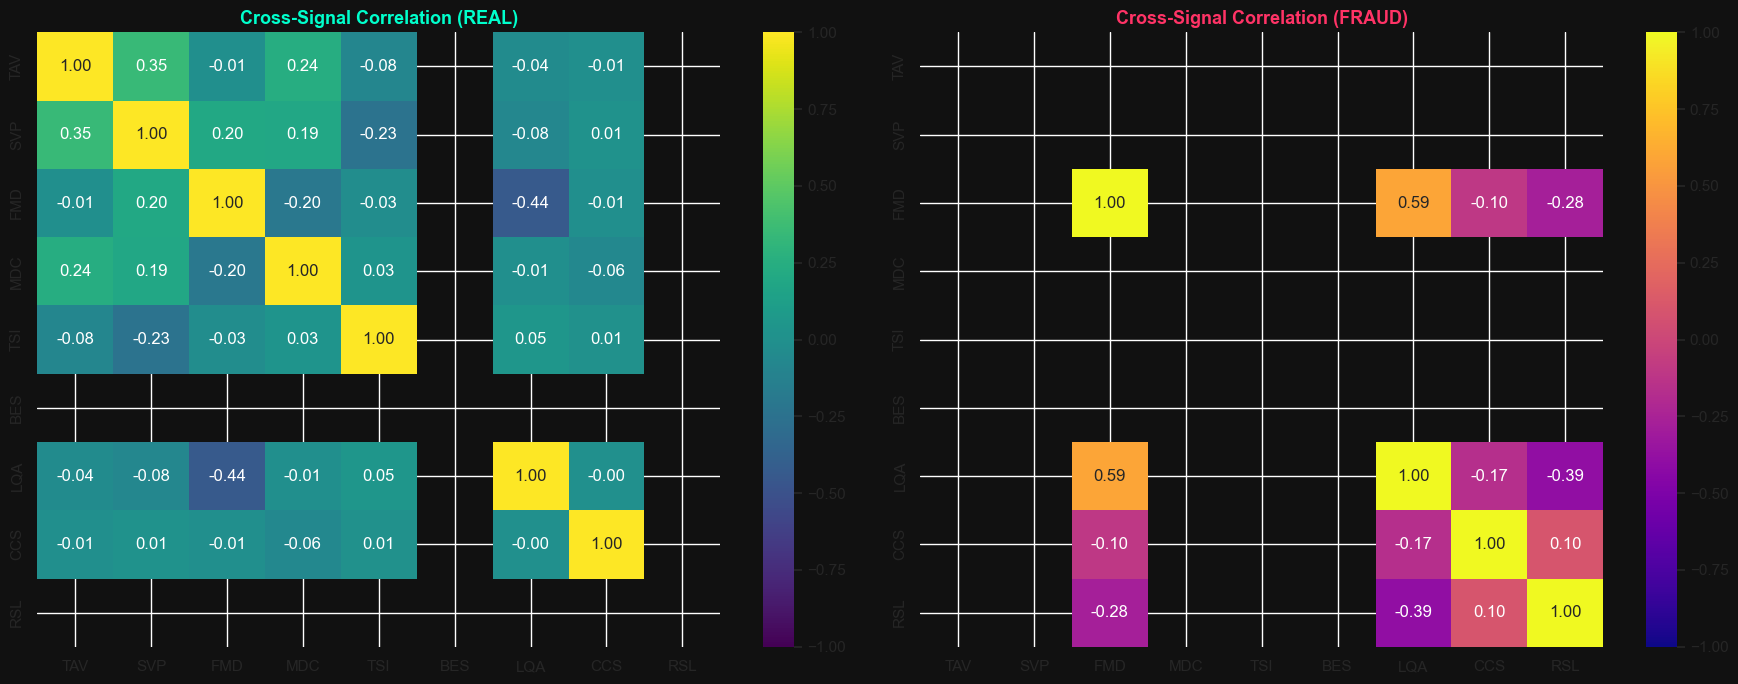

In [18]:
# --- Cross-Signal Correlation Heatmaps ---
signals = ['tav_score','svp_score','fmd_score','mdc_score','tsi_score',
           'bes_score','lqa_score','ccs_score','rsl_score']
existing = [s for s in signals if s in df.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

real_corr = df[df['label']=='REAL'][existing].corr()
fraud_corr = df[df['label']=='FRAUD'][existing].corr()

labels = [s.replace('_score','').upper() for s in existing]

sns.heatmap(real_corr, annot=True, cmap='viridis', vmin=-1, vmax=1, ax=ax1,
           xticklabels=labels, yticklabels=labels, fmt='.2f')
ax1.set_title("Cross-Signal Correlation (REAL)", color='#00ffcc', fontsize=13, fontweight='bold')

sns.heatmap(fraud_corr, annot=True, cmap='plasma', vmin=-1, vmax=1, ax=ax2,
           xticklabels=labels, yticklabels=labels, fmt='.2f')
ax2.set_title("Cross-Signal Correlation (FRAUD)", color='#ff3366', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
